# Lab Three: Extending Logistic Regression

Group Members: David Guo, Zi Ling

## 1. Preparation and Overview

### 1.1 Business Case and Task Overview

Amazon provides an open marketplace for online shopping, and millions of sellers are competing with each other to win more sales revenue. In this competitive environment, effective marketing strategies are essential for sellers to attract potential consumers and drive sales performance, especially in a market where the product supply exceeds demand and consumer attention has become a scarce resource.

In this project, we aim to build a classification model that predicts the sales performance level of electronic products. To achieve the classification, we continue working on the dataset in Lab One -Amazon Product Sales Dataset, define the sales class as High, Medium, and Low based on sales revenue, find relative features, such as discount price, sponsorship label, customer rating, and total reviews, and build the predictive model.

With this model, Amazon electronic product sellers can forecast sales outcomes on different promotional and advertising toolkits and adjust the strategies to achieve higher sales performance before implementation, which can optimize advertising budgets, improve conversion rates, and reduce unnecessary spending.

This model is intended for offline analysis because in real-world decision-making, a marketing strategy usually needs to be prepared, analyzed, and reported offline, and then applied to the products. Therefore, online analysis is not worth the cost. Moreover, the data is scraped from Amazon and the sales revenue usually lags behind marketing activities, so real-time analysis does not provide much value. But, daily analysis, like input the marketing tooklit into the model and get the output predict level, is still necessary, as it allows us to monitor product sales performance and observe competitors' marketing strategies, so that we can adjust our own strategies in time. In addition, the model needs to be retrained weekly, since the shopping festivel, promotion event and competitor strategies are changed repidly, model needs to be modified based on new data scrapped from Amazon.

Considering the model's effectiveness and daily analysis efficiency, the model should have both high accuracy and high performance. According to “2025 Marketing Budget for Ecommerce Companies” from WebFX, ecommerce companies spend 10-20% of revenue on marketing[1]. Combining with the Amazon dataset, half of the sellers will spend 1,600-3,200 dollars, and 1/4 top sellers will spend 8,000-16,000 dollars per month. So our accuracy needs to be as high as possible in a rational range, and not overfitting in the current dataset. As a simplified baseline, we can assume that a human decision is like a random guess, which gives 50% accuracy, and based on our expectation, 80% accuracy is the baseline for seller to trust model, which will save at least 2,400-4,800 dollars for top sellers per month. 90% or above accuracy would be a more convincing and reliable result to let the sellers make decisions based on the model, which will save at least $3,200-6,400 per month.


=====================================================================================================

Dataset URL: https://www.kaggle.com/datasets/ikramshah512/amazon-products-sales-dataset-42k-items-2025/data

Questions of Interest: Predict the electronic product sales level on Amazon, based on giving marketing strategies (discount, sponsor, etc.)

### 1.2 Lab One Dataset Description

In [ ]:
# Read cleaned dataset from Lab1

import pandas as pd

df = pd.read_csv("cleaned_amazon_electronic_product.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30304 entries, 0 to 30303
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30304 non-null  float64
 1   total_reviews                         30304 non-null  int64  
 2   purchased_last_month                  30304 non-null  int64  
 3   discounted_price                      30304 non-null  float64
 4   original_price                        30304 non-null  float64
 5   is_sponsored                          30304 non-null  float64
 6   discount_percentage                   30304 non-null  float64
 7   product_category_Cameras              30304 non-null  float64
 8   product_category_Chargers & Cables    30304 non-null  float64
 9   product_category_Gaming               30304 non-null  float64
 10  product_category_Headphones           30304 non-null  float64
 11  product_categor

In [ ]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_sponsored,discount_percentage,product_category_Cameras,product_category_Chargers & Cables,product_category_Gaming,...,is_best_seller_Best Seller,is_best_seller_Ends in,is_best_seller_Limited time deal,is_best_seller_No Badge,is_best_seller_Save 12%,is_best_seller_Save 17%,is_best_seller_Save 18%,is_best_seller_Save 30%,sales_volume,sales_revenue
count,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.00000,30304.000000,...,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,30304.000000,3.030400e+04
mean,4.438351,3689.082068,1351.323258,156.685623,173.071625,0.118829,7.838263,0.082167,0.05095,0.014784,...,0.008547,0.003201,0.013266,0.944298,0.000858,0.001683,0.001881,0.004125,1351.323258,5.200313e+04
std,0.358686,14815.948168,6468.851360,258.200836,306.117691,0.323593,13.576652,0.274624,0.21990,0.120687,...,0.092054,0.056487,0.114412,0.229350,0.029279,0.040990,0.043330,0.064094,6468.851360,1.753726e+05
min,2.000000,1.000000,50.000000,2.160000,2.160000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,6.000000e+02
25%,4.300000,165.000000,100.000000,25.470000,28.910000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.000000,6.999875e+03
50%,4.500000,686.000000,200.000000,74.990000,78.990000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,200.000000,1.359550e+04
75%,4.700000,2646.500000,400.000000,182.922500,199.000000,0.000000,12.710000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,400.000000,2.699500e+04
max,5.000000,865598.000000,100000.000000,4198.000000,4299.000000,1.000000,85.420000,1.000000,1.00000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100000.000000,9.995000e+06



In Lab One, we finished feature selection, data cleaning and data type correctness and created a new dataset.

In the feature selection phase, we selected 9 features from 17 features, removed useless features like product_name, image_url, and features with so many missing values, such as sustainability_tags, has_coupon.

In the data cleaning phase, we deleted rows and features with so many missing values, and imputed 0.25% missing values in product rating using KNN.

In the data type correctness phase, we transformed is_sponsored, product_category, and is_best_seller into one-hot-encoding features, and kept the original features as sponsor_label, category_label, and best_seller label for visualization.

We also defined features to show the sales performance: sales_volume by purchase_last_month, and sales_revenue by multiplying purchase_last_month by discounted_price.


### 1.3 Define Class Label

In [ ]:
# find 25% and 75% in sales_revenue

# define sales_level lables
q1 = df["sales_revenue"].quantile(0.25)
q3 = df["sales_revenue"].quantile(0.75)

def sales_level(x):
	if x <= q1:
		return 1   # Low
	elif x >= q3:
		return 3   # High
	else:
		return 2   # Medium

#add to dataframe
df["sales_level"] = df["sales_revenue"].apply(sales_level)

print(df['sales_level'].value_counts().sort_index())

sales_level
1     7576
2    15111
3     7617
Name: count, dtype: int64


In this Lab, we create sales_level as the class label to predict, which represents the sales revenue level of each product. These classification labels can tell sellers the product's position in the market, rather than just its raw sales output, such as counts, or revenue

We defined three classes:

1. Low: product in the bottom 25% sales revenue, including 7,576 products.

2. Medium: product in the middle, 25-75% sales revenue, including 15,111 products.

3. High: products in the top 25% sales revenue, including 7,617 products.

Since this variable represents ordered categories, we define it as an integer, with Low level being 1, Medium level being 2, and High level being 3. This keeps the natural order (Low < Medium < High) and makes it more efficient for modeling.

### 1.4 Remove Useless Features

In [ ]:
# Remove derived and non-numerical categorical variables
df_cleaned = df.drop(columns=['purchased_last_month', 'sales_volume', 'sales_revenue',
	'category_label', 'best_seller_label', 'discount_flag', 'sponsor_label'
])

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30304 entries, 0 to 30303
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   product_rating                        30304 non-null  float64
 1   total_reviews                         30304 non-null  int64  
 2   discounted_price                      30304 non-null  float64
 3   original_price                        30304 non-null  float64
 4   is_sponsored                          30304 non-null  float64
 5   discount_percentage                   30304 non-null  float64
 6   product_category_Cameras              30304 non-null  float64
 7   product_category_Chargers & Cables    30304 non-null  float64
 8   product_category_Gaming               30304 non-null  float64
 9   product_category_Headphones           30304 non-null  float64
 10  product_category_Laptops              30304 non-null  float64
 11  product_categor


To build the model, we removed variables that are not useful or appropriate:

1. Remove derived variables that may cause data leakage and influence the accuracy, which are purchased_last_month, sales_volume, and sales_revenue.

2. Remove Non-numerical variables that we already did one-hot-encoding, which are category_label, best_seller_label, discount_flag, and sponsor_label.

### 1.5 Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

# separate features and target
X = df_cleaned.drop(columns=['sales_level'])
y = df_cleaned['sales_level']

# scale numeric features
X_scaled = StandardScaler().fit(X).transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=X.columns)


df_scaled.head()

,product_rating,total_reviews,discounted_price,original_price,is_sponsored,discount_percentage,product_category_Cameras,product_category_Chargers & Cables,product_category_Gaming,product_category_Headphones,...,product_category_Wearables,is_best_seller_Amazon's,is_best_seller_Best Seller,is_best_seller_Ends in,is_best_seller_Limited time deal,is_best_seller_No Badge,is_best_seller_Save 12%,is_best_seller_Save 17%,is_best_seller_Save 18%,is_best_seller_Save 30%
0,0.450678,-0.223687,-0.259514,-0.045969,2.723131,2.634105,-0.299204,-0.231702,-0.122496,-0.183388,...,-0.119833,-0.150478,-0.092846,-0.056667,-0.115948,0.242874,-0.029304,-0.041058,-0.043411,-0.064358
1,-0.385722,-0.083161,-0.568155,-0.513150,2.723131,2.186270,-0.299204,-0.231702,-0.122496,-0.183388,...,-0.119833,-0.150478,-0.092846,-0.056667,-0.115948,0.242874,-0.029304,-0.041058,-0.043411,-0.064358
2,0.450678,-0.043540,0.609281,0.574718,2.723131,0.161437,-0.299204,-0.231702,-0.122496,-0.183388,...,-0.119833,-0.150478,-0.092846,-0.056667,-0.115948,0.242874,-0.029304,-0.041058,-0.043411,-0.064358
3,0.450678,2.172892,0.021512,-0.035384,-0.367224,-0.577344,-0.299204,-0.231702,-0.122496,-0.183388,...,-0.119833,-0.150478,10.770509,-0.056667,-0.115948,-4.117354,-0.029304,-0.041058,-0.043411,-0.064358
4,1.008278,1.707575,-0.325123,-0.327760,-0.367224,-0.577344,-0.299204,-0.231702,-0.122496,-0.183388,...,-0.119833,-0.150478,-0.092846,-0.056667,-0.115948,0.242874,-0.029304,-0.041058,-0.043411,-0.064358


**Scaling:**

Since the range of each variable is not balanced, for example, product rating is from 2 to 5, while total reviews is from 1 to 865,598, and to reduce outliers and prevent large range value variables from dominating the model, we performed scaling on the features.

**Dimensional Reduction:**

Since we only have 30 features, and 24 of them are one-hot-encoding from 2 features, so the dimensions are already small, so no need to conduct dimensional reduction.

### 1.6 Final Dataset Description

In [ ]:
# final dataset
X = df_scaled
y = y = df_cleaned['sales_level']

# Combine into one dataframe
df_final = pd.concat([X, y], axis=1)

# Show statistics
df_final.describe().T


,count,mean,std,min,25%,50%,75%,max
product_rating,30304.0,7.085732e-16,1.000016,-6.798121,-0.385722,0.171878,0.729478,1.565878
total_reviews,30304.0,7.503091e-18,1.000016,-0.248931,-0.237861,-0.202696,-0.070370,58.175361
discounted_price,30304.0,1.012917e-16,1.000016,-0.598481,-0.508200,-0.316409,0.101616,15.652084
original_price,30304.0,-1.500618e-17,1.000016,-0.558329,-0.470943,-0.307343,0.084702,13.478465
is_sponsored,30304.0,2.250927e-17,1.000016,-0.367224,-0.367224,-0.367224,-0.367224,2.723131
discount_percentage,30304.0,1.406830e-16,1.000016,-0.577344,-0.577344,-0.577344,0.358838,5.714444
product_category_Cameras,30304.0,7.503091e-18,1.000016,-0.299204,-0.299204,-0.299204,-0.299204,3.342197
product_category_Chargers & Cables,30304.0,-1.359935e-17,1.000016,-0.231702,-0.231702,-0.231702,-0.231702,4.315894
product_category_Gaming,30304.0,9.378864e-18,1.000016,-0.122496,-0.122496,-0.122496,-0.122496,8.163508
product_category_Headphones,30304.0,5.627318e-17,1.000016,-0.183388,-0.183388,-0.183388,-0.183388,5.452915


The final dataset contains 30 predictor variables and 30,304 product records after processing.

The product_rating, total_reviews, discounted_price, original_price, is_sponsored and discounted_percentage are numerical featured, and product_category is one-hot-encoding into 15 features, and is_best_seller is one-hot-encoding into 9 features.

The product_rating and total_reviews are related to the reviews management strategy, the discounted_price, original_price, and discounted_percentage are related to the promotion strategy, the is_sponsored and is_best_seller are related to the advertising strategy, and the product_category is related to the product attribute.

After scaling, the statistics of the variables are consistent-scaled, most features have a mean close to 0 and standard deviation close to 1.

Additionally, we created a new classification variable - sales_level in Low (1), Medium (2), and High (3) based on sales_revenue, to represent the sales performance of the product in the market, it is also our target variable.

### 1.7 Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size=0.2)

print(y_train.value_counts())
print(y_test.value_counts())
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


sales_level
2    12044
3     6175
1     6024
Name: count, dtype: int64
sales_level
2    3067
1    1552
3    1442
Name: count, dtype: int64
sales_level
2    0.496803
3    0.254713
1    0.248484
Name: proportion, dtype: float64
sales_level
2    0.506022
1    0.256063
3    0.237915
Name: proportion, dtype: float64


We split the dataset into 80% training and 20% testing using scikit-learn, and we think 80/20 works for our data, because:

1. We have enough data (30,304 product rows) to learn, and after splitting, the train part has 24,243 rows, and the test part still has 6,601 rows.

2. Based on the abundant data in the training part, the model is good to learn the pattern. If we smaller the test part into 10%, the evaluation robustness may be reduced, or if we create a larger one as 30%, the trainning data will be reduced into 70%, which is unnecessary.

3. The rows are isolated, don't have dependencies with each other, so randomly split is effective here.

4. The sales_level distribution in train and test is almost the same, so they are still representative.

## 2. Modeling

### 2.1 One-versus-all Logistc Regression

In [ ]:
#Asked GPT to debug some problems.
import numpy as np
from scipy.special import expit
from numpy.linalg import pinv

class OneVsAllLogisticRegression:
	def __init__(self, eta, solver, penalties, iterations=20, C=0.001, mini_batch = 32):
		self.eta = eta
		self.iters = iterations
		self.C = C
		self.penalties = penalties.lower()
		self.solver = solver.lower()
		self.mini_batch_size = mini_batch
		self.optimization_method = {
				"steepest ascent": self.steepest_ascent,
				"stochastic gradient ascent": self.stochastic_gradient_ascent,
				"newton method": self.newton_method
		}

		if self.solver == "newton method" and self.penalties in {"l1", "elasticnet"}:
				raise ValueError(
						"Newton's method is only valid for 'none' or 'l2' regularization "
						"because L1 introduces non-differentiable terms."
				)

		if solver in self.optimization_method:
				self.solver = self.optimization_method[self.solver]
		else:
				raise ValueError("Solver given is not in the list")

	def __str__(self):
		if hasattr(self, "w_"):
			return "Binary Logistic Regression Object with coefficients:\n" + str(self.w_)
		else:
			return "Untrained Binary Logistic Regression Object"

	def steepest_ascent(self, X, y):
		for _ in range(self.iters):
			gradient = self._get_gradient(X, y)
			self.w_ += self.eta * gradient

	def stochastic_gradient_ascent(self, X, y):
		batch_size = min(self.mini_batch_size, X.shape[0])

		for _ in range(self.iters):
			indices = np.random.permutation(X.shape[0])

			for start in range(0, X.shape[0], batch_size):
				end = start + batch_size
				batch_idx = indices[start:end]
				X_batch = X[batch_idx]
				y_batch = y[batch_idx]
				grad = self._get_gradient(X_batch, y_batch)
				self.w_ += self.eta * grad

	def newton_method(self, X, y):
		for _ in range(self.iters):
			gradient = self._get_gradient(X, y)

			pred = self.predict_proba(X, add_bias=False).ravel()
			y_flat = y.ravel()
			W = pred * (1 - pred)
			H = (X.T @ (W[:, np.newaxis] * X)) / len(y_flat)

			H += 1e-5 * np.eye(H.shape[0])

			if self.penalties == "l2" or self.penalties == "elasticnet":
				reg_matrix = np.zeros_like(H)
				reg_matrix[1:, 1:] = 2 * self.C * np.eye(H.shape[0] - 1)
				H += reg_matrix

			direction = np.linalg.solve(H, gradient)
			self.w_ += direction

	@staticmethod
	def _add_bias(X):
		return np.hstack((np.ones((X.shape[0], 1)), X))

	@staticmethod
	def _sigmoid(theta):
		return expit(theta)

	def _get_gradient(self, X, y):
		y_flat = y.ravel()
		pred_flat = self.predict_proba(X, add_bias=False).ravel()
		error = y_flat - pred_flat
		gradient = (X.T @ error) / len(y_flat)
		gradient = gradient.reshape(-1, 1)

		if self.penalties == "l1":
			gradient[1:] -= self.C * np.sign(self.w_[1:])
		elif self.penalties == "l2":
			gradient[1:] -= 2 * self.C * self.w_[1:]
		elif self.penalties == "elasticnet":
			gradient[1:] -= self.C * np.sign(self.w_[1:])
			gradient[1:] -= 2 * self.C * self.w_[1:]

		return gradient

	def predict_proba(self, X, add_bias=True):
		if add_bias:
			Xb = self._add_bias(X)
		else:
			Xb = X

		if hasattr(self, 'all_weights') and not isinstance(self.all_weights, list):
			logits = Xb @ self.all_weights
			return self._sigmoid(logits)

		return self._sigmoid(Xb @ self.w_)

	def predict(self, X):
		proba = self.predict_proba(X)
		if proba.ndim == 1:
			return (proba > 0.5).astype(int)
		return self.classes[np.argmax(proba, axis=1)]

	def fit(self, X, y):
		if hasattr(y, 'values'):
			y = y.values
		if hasattr(X, 'values'):
			X = X.values

		Xb = self._add_bias(X)
		self.classes = np.unique(y)
		self.all_weights = []

		for cls in self.classes:
			y_binary = (y == cls).astype(int).reshape(-1, 1)
			self.w_ = np.zeros((Xb.shape[1], 1))
			self.solver(Xb, y_binary)
			self.all_weights.append(self.w_.copy())

		self.all_weights = np.hstack(self.all_weights)
		return self

**Breakdown of the code:**

We implemented the following optimization methods: Steepest Ascent, Stochastic Gradient Ascent, and Newton Method. Steepest Ascent is used to update the weights using the gradient and how big of a step it takes to find the optima result. Stochastic Gradient Ascent was implemented using mini batch, as this was much faster to compute than my previous attempt of getting random samples. Finally the newton method was implemented by calculating the second order derivatives, as this ensures the a more precise curvature-aware steps. Additionally, we also restricted Newton Method to be only run when the penalty is l2.

The penalty was implemented with support for l1, l2, elastic and none. L1 adds a penalty proportional value to the coefficients, this encourages sparsity close to zero. L2 penalized the squared magnitude of the weight, and this discourage large coefficients. Elasticnet combines both l1, and l2, which balances sparsity and coefficients shrinkage. Finally, there is none so no penalty is applied.

### 2.2 Model Training

In [ ]:
#Splitting the testing in to training and validation set
tuning_X_train, tuning_X_val, tuning_y_train, tuning_y_val = train_test_split(
		X_train, y_train, train_size=0.75, test_size=0.25,
		random_state=42, stratify=y_train
)

**Reason for splitting:**

We are further split our training dataset in to train and validation set, this ensures that that the test set was never used for the tuning process, and all the hyper parameter selection were done based on the validation set. As a result, we can avoid data snooping issue. As this prevents the model from seeing or snooping the data  during the tuning phase, which could result lead to a overfitting issue. This is

In [ ]:
from sklearn.metrics import accuracy_score
import time

hyper_params = {
	'solver': ['steepest ascent', 'stochastic gradient ascent', 'newton method'],
	'penalties': ['none', 'l1', 'l2', 'elasticnet'],
	'C': [0.0001, 0.001, 0.01, 0.1, 1.0],
	'eta': [0.001, 0.01, 0.1],
	'iterations': [50, 100, 200]
}

results = []
highest_result = []

max_tunning_result = None

for solver in hyper_params['solver']:
	for penalty in hyper_params['penalties']:
		if solver == "newton method" and penalty in {"l1", "elasticnet"}:
				continue

		for C in hyper_params['C']:
			for eta in hyper_params['eta']:
				for iterations in hyper_params['iterations']:
					model = OneVsAllLogisticRegression(
						eta=eta,
						solver=solver,
						penalties=penalty,
						iterations=iterations,
						C=C,
						mini_batch=64
					)

					start_time = time.time()
					model.fit(tuning_X_train, tuning_y_train)
					train_time = time.time() - start_time

					y_train_pred = model.predict(tuning_X_train)
					y_val_pred = model.predict(tuning_X_val)

					train_acc = accuracy_score(tuning_y_train, y_train_pred)
					val_acc = accuracy_score(tuning_y_val, y_val_pred)

					results.append({
							'solver': solver,
							'penalty': penalty,
							'C': C,
							'eta': eta,
							'iterations': iterations,
							'train_accuracy': train_acc*100,
							'val_accuracy': val_acc*100,
							'train_time': train_time,
							'overfit_gap': train_acc - val_acc
					})

results_df = pd.DataFrame(results)

In [ ]:
print(results_df.sort_values(by='val_accuracy', ascending=False).head(5))

                         solver     penalty       C  eta  iterations  \
195  stochastic gradient ascent        none  0.0010  0.1          50   
196  stochastic gradient ascent        none  0.0010  0.1         100   
322  stochastic gradient ascent  elasticnet  0.0001  0.1         100   
240  stochastic gradient ascent          l1  0.0010  0.1          50   
215  stochastic gradient ascent        none  0.1000  0.1         200   

     train_accuracy  val_accuracy  train_time  overfit_gap  
195       70.888791     70.862894    1.104397     0.000259  
196       70.668793     70.829896    2.151063    -0.001611  
322       70.448796     70.417423    2.727805     0.000314  
240       70.289297     70.384425    2.013165    -0.000951  
215       70.569794     70.334928    5.607174     0.002349  


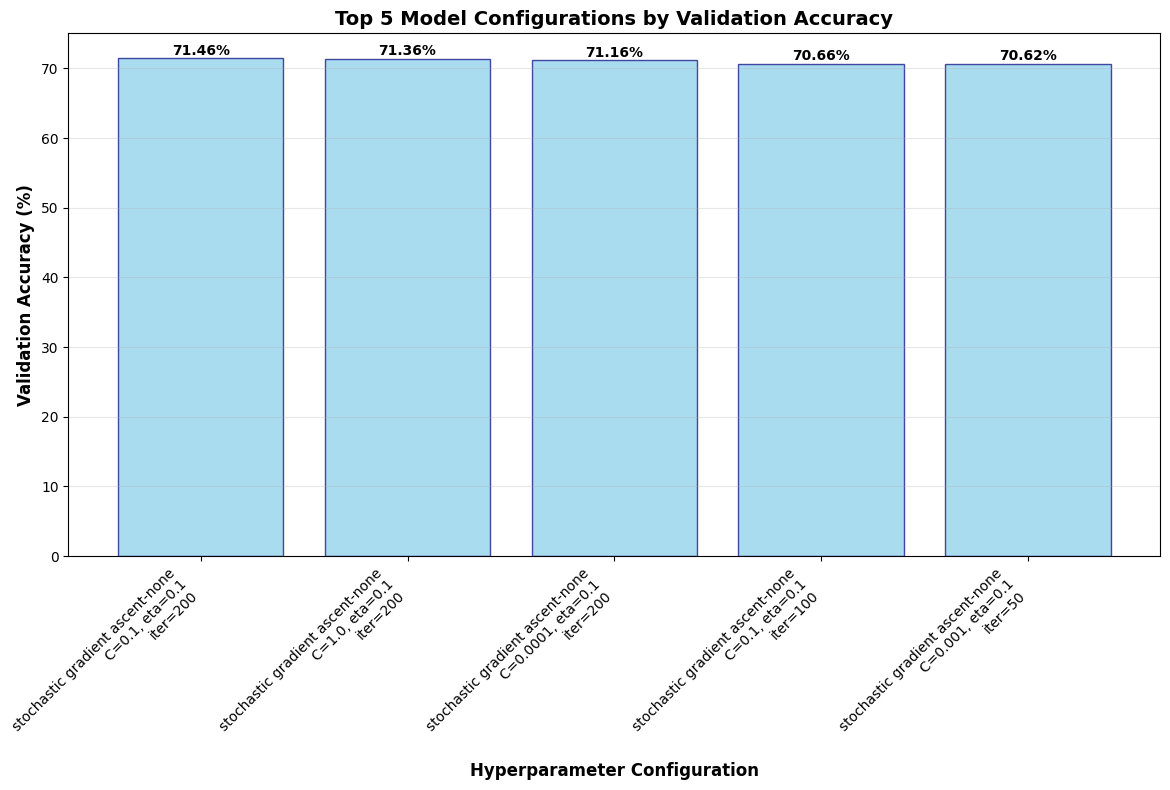

In [ ]:
#Asked Gpt to make the graph more readable with the tune labels
import matplotlib.pyplot as plt

top_5_results = results_df.nlargest(5, 'val_accuracy').reset_index(drop=True)

top_5_results['config'] = top_5_results.apply(
	lambda row: f"{row['solver']}-{row['penalty']}\nC={row['C']}, eta={row['eta']}\niter={row['iterations']}",
	axis=1
)

plt.figure(figsize=(12, 8))
bars = plt.bar(top_5_results['config'], top_5_results['val_accuracy'], color='skyblue', edgecolor='navy', alpha=0.7)

for bar, accuracy in zip(bars, top_5_results['val_accuracy']):
	plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
			 f'{accuracy:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Hyperparameter Configuration', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Top 5 Model Configurations by Validation Accuracy', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

**Analysis of the top 5 model:**

From the graph above, stochastic gradient ascent had the best performer in the top 5 result. Using a variety of tunning parameters, we were mainly getting similar result. As such picking any tuning result will give us a good performance of the model as the difference between the top performer and worst performer is 0.84% difference which is negligible.

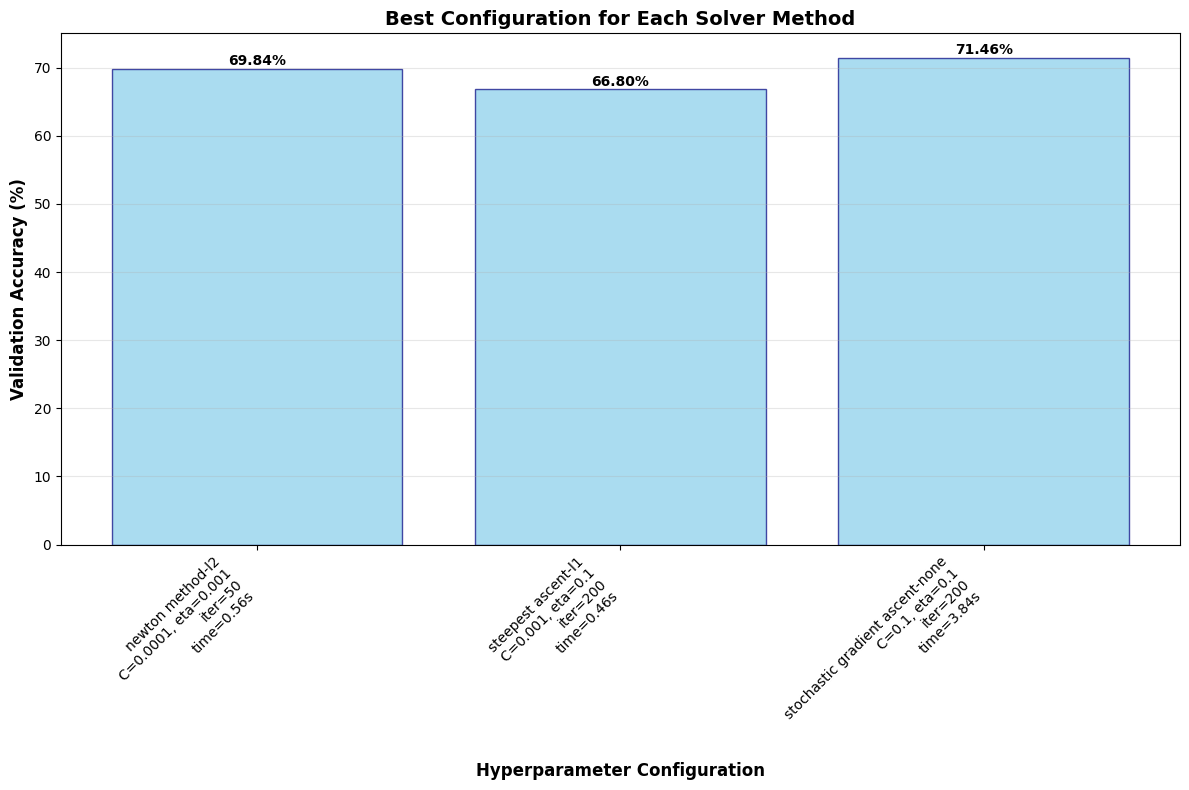

In [ ]:
top_per_solver = results_df.loc[results_df.groupby('solver')['val_accuracy'].idxmax()].reset_index(drop=True)

top_per_solver['config'] = top_per_solver.apply(
	lambda row: f"{row['solver']}-{row['penalty']}\nC={row['C']}, eta={row['eta']}\niter={row['iterations']}\ntime={row['train_time']:.2f}s",
	axis=1
)

plt.figure(figsize=(12, 8))
bars = plt.bar(top_per_solver['config'], top_per_solver['val_accuracy'], color='skyblue', edgecolor='navy', alpha=0.7)

for bar, accuracy in zip(bars, top_per_solver['val_accuracy']):
	plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
			 f'{accuracy:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Hyperparameter Configuration', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Best Configuration for Each Solver Method', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

**Analysis of the best model by solver method:**

We can see that steepest ascent had the worst performance out of the three method with a validation accuracy off 66.80%. Newton method, and stochastic gradient ascent did have almost the same performance of 69.84% and 71.46% respectively. However, we can see that there is a major time difference in the time it took to train the model. Newton method took 0.56s, and SGA took 3.84s. While our dataset is normal size of 30k data, if we were to deploy this model on a large scale dataset like around 500K then the time taken to train the model becomes expensive when using stochastic gradient ascent. Compared to a newton method which only took 0.56s, it would perform better with a larger dataset.

However, since our model is an offline model, the time taken is not a important metric as we can train the model overnight, as such going with the best performer is recommended if we want to predict which sales level this product will have into.

We selected the configuration with the highest validation accuracy as the final model, as the validation data was never exposed during training.

### 2.3 Performance Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


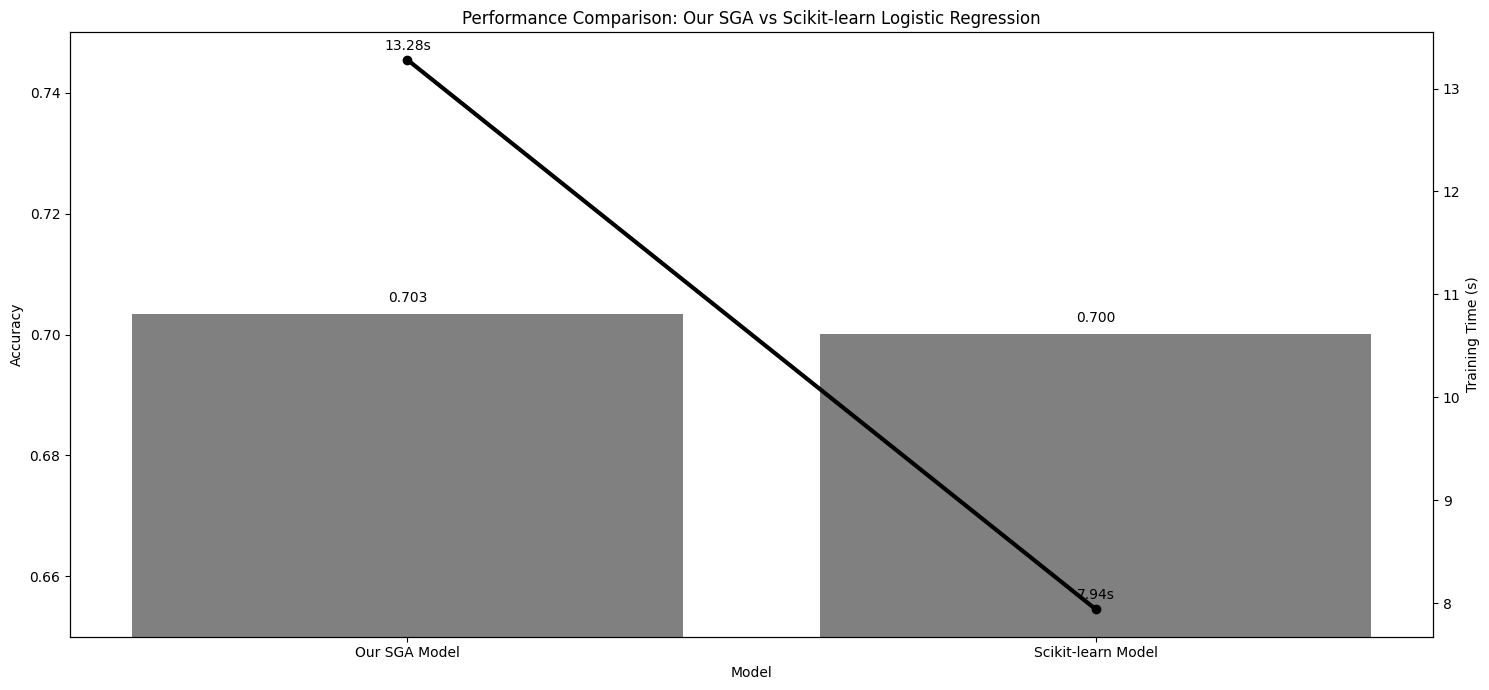

In [ ]:
# asked GPT about scikit learn parameter tuning

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import time

# using the Stochastic Gradient Ascent with the best penaities
sga_model = OneVsAllLogisticRegression(eta=0.1, solver="stochastic gradient ascent", penalties="l1", iterations=200, C=0.0001)
start = time.time()
sga_model.fit(X_train, y_train)
sga_time = time.time() - start
sga_acc = accuracy_score(y_test, sga_model.predict(X_test))

# sklearn with matched regularization strength
C_sk = 1.0 / 0.0001
sk_model = LogisticRegression(penalty='l1', solver='saga', C=C_sk, max_iter=200)

start = time.time()
sk_model.fit(X_train, y_train)
sk_time = time.time() - start
sk_acc = accuracy_score(y_test, sk_model.predict(X_test))

models = ['Our SGA Model', 'Scikit-learn Model']
accuracy = [sga_acc, sk_acc]
time = [sga_time, sk_time]

fig, ax1 = plt.subplots(figsize=(15,7))

# accuracy
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
bars = ax1.bar(models, accuracy, color='grey', label='Accuracy')
ax1.tick_params(axis='y')
ax1.set_ylim(0.65, 0.75)
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.002, f"{v:.3f}", ha='center')

# time
ax2 = ax1.twinx()
ax2.set_ylabel('Training Time (s)')
ax2.plot(models, time, color='black', marker='o', linewidth=3, label='Time')
ax2.tick_params(axis='y')
for i, t in enumerate(time):
    ax2.text(i, t + 0.1, f"{t:.2f}s", ha='center')

plt.title('Performance Comparison: Our SGA vs Scikit-learn Logistic Regression')
fig.tight_layout()
plt.show()

To ensure a fair comparison, we matched the regularization strength between the two implementations: The C value of scikit-learn is the inverse of λ; both models use L1 regularization; and both models have the same iteration times as 200.

In these parameters, scikit-learn raised a warning indicating that the optimization process had not fully converged yet, which means the accuracy will be lower than a fully converged model. But according to the result, their accuracies are pretty close, with only a 0.003 gap. However, scikit-learn costs much less time of our SGA model.

This result demonstrates that although our SGA implementation achieved comparable performance, scikit-learn wins more in time efficiency.

,Sales Level,SGA Accuracy,Scikit-learn Accuracy
0,1 (Low),0.547036,0.644974
1,2 (Medium),0.817411,0.743724
2,3 (High),0.575589,0.565881


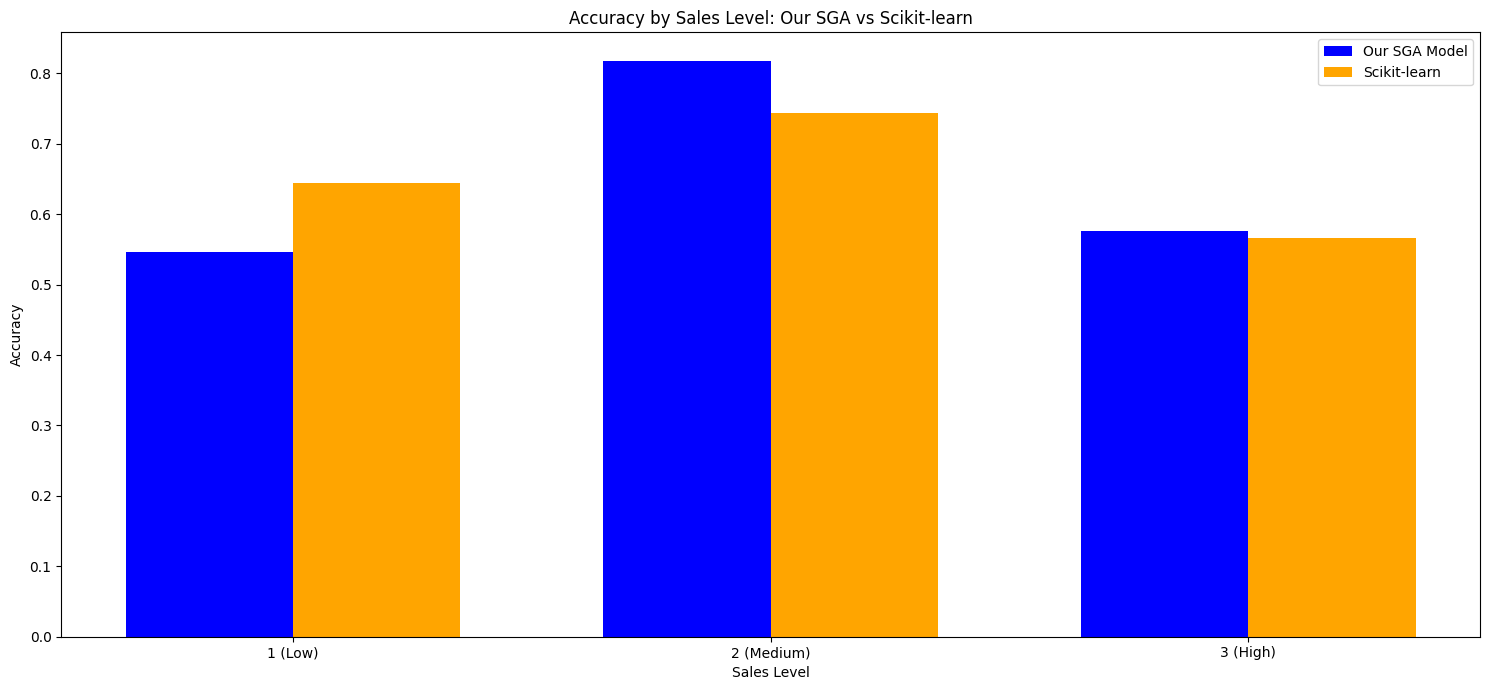

In [ ]:
# accuracy in sales_levels

sga_pred = sga_model.predict(X_test)
sk_pred = sk_model.predict(X_test)

comparison_df = pd.DataFrame({
    'true': y_test,
    'sga_pred': sga_pred,
    'sk_pred': sk_pred
})

# Define mapping for sales level labels
sales_labels = {
    1: "1 (Low)",
    2: "2 (Medium)",
    3: "3 (High)"
}

# Compute accuracy per class (sales level)
sales_levels = sorted(y_test.unique())
sga_acc_by_class = []
sk_acc_by_class = []

for level in sales_levels:
    level_idx = (comparison_df['true'] == level)
    sga_acc = accuracy_score(comparison_df.loc[level_idx, 'true'], comparison_df.loc[level_idx, 'sga_pred'])
    sk_acc = accuracy_score(comparison_df.loc[level_idx, 'true'], comparison_df.loc[level_idx, 'sk_pred'])
    sga_acc_by_class.append(sga_acc)
    sk_acc_by_class.append(sk_acc)

# create summary DataFrame with readable labels
acc_compare = pd.DataFrame({
    'Sales Level': [sales_labels[l] for l in sales_levels],
    'SGA Accuracy': sga_acc_by_class,
    'Scikit-learn Accuracy': sk_acc_by_class
})

display(acc_compare)

# visualization
plt.figure(figsize=(15,7))
bar_width = 0.35
x = range(len(sales_levels))

plt.bar(x, sga_acc_by_class, width=bar_width, label='Our SGA Model', color='blue')
plt.bar([i + bar_width for i in x], sk_acc_by_class, width=bar_width, label='Scikit-learn', color='orange')

plt.xlabel('Sales Level')
plt.ylabel('Accuracy')
plt.title('Accuracy by Sales Level: Our SGA vs Scikit-learn')
plt.xticks([i + bar_width/2 for i in x], [sales_labels[l] for l in sales_levels])
plt.legend()
plt.tight_layout()
plt.show()

Despite the overall accuracy, we also want to know the predict effectiveness in each sales level, because the most important levels are Low level and High level, if the model miss-classify the low level into the high level, sellers will lost money on useless markteting strategies.

According to the table and the chart, our SGA model achieved better accuracy in Medium level, scikit-learn performed better in Low level, and both models are close in the High level, with SGA slightly higher (about 0.01) than scilite-learn.

In summary, Scikit-learn wins in the sales level accuracy, because it has a better posibility to recognize Low level product, which is a good news for the sellers, because it could help sellers to avoid bad marketing strategy.

## 3.Deployment

We recommend using the scikit-learn implementation of logistic regression for the following reasons:
1. The overall accuracy of our SGA implementation is 0.003 higher than Scikit-learn, and the medium level accuracy is also higher (around 0.03). But, the critical predictive results that sellers care about are the Low level and High level. In High Level, our SGA has a 0.01 higher accuracy than Scikit-learn, but has a 0.06 lower accuracy in Low Level, which means that Scikit-learn has a better accuracy to help sellers to avoid making wrong decisions and lose money. Therefore, in the accuracy comparison, we believe Scikit-learn is better for the sellers.

2.  Scikit-learn's implementation runs much faster than our SGA implementation, which saved 38% time on a 30k-columns dataset. And considering there are 45 million products on Amazon [2], the performance gap will be higher between these two implementations. For the sellers on Amazon, they need to adjust marketing strategies frequently, so the model needs to be run to predict sales level daily and retrained on new data scraped from Amazon weekly, in this way they can follow the market promotion trend better. Therefore, time is very important, and Scikit-learn is better.

3. Scikit-learn is extensively tested and debugged, and maintained by a large open-source community. Therefore, it's more reliable and stable than our implementation, and requires lower maintenance effort in long-term usage. For the sellers, more time spent in debugging and maintenance means more money they should spend, so considering minimizing these expenses, Scikit-learn is a better implementation.

Therefore, scikit-learn’s implementation is the preferred choice for deployment in real-world applications.

In addition, both model didn't meet our expectation of the accuracy, because they only achieve 70% accuracy while our baseline is 80%. So in real-world usage, sellers can't fully rely on either SGA or Scikit-learn, but the model can be used as a reference, since it's still better than flipping a coin. For further work, we need to include more data and build a higher accuracy model and improve reliability.

### Exceptional Work

In [ ]:
# !git clone https://github.com/rapidsai/rapidsai-csp-utils.git
# !python rapidsai-csp-utils/colab/pip-install.py

In [ ]:
import time

# RAPIDS imports
from cuml.linear_model import LogisticRegression
from cuml.multiclass import OneVsRestClassifier
from cuml.preprocessing import StandardScaler
from cuml.metrics import accuracy_score

C_sk = 1.0 / 0.0001
cuda_logistic_regression = LogisticRegression(
    penalty='l1', solver='qn', C=C_sk, max_iter=200
)
cuda_logistic_regression_ovr = OneVsRestClassifier(cuda_logistic_regression)

start = time.time()
cuda_logistic_regression_ovr.fit(X_train, y_train)
cuda_ovr_time = time.time() - start

cuda_logistic_regression_ovr_acc = accuracy_score(y_test, cuda_logistic_regression_ovr.predict(X_test))

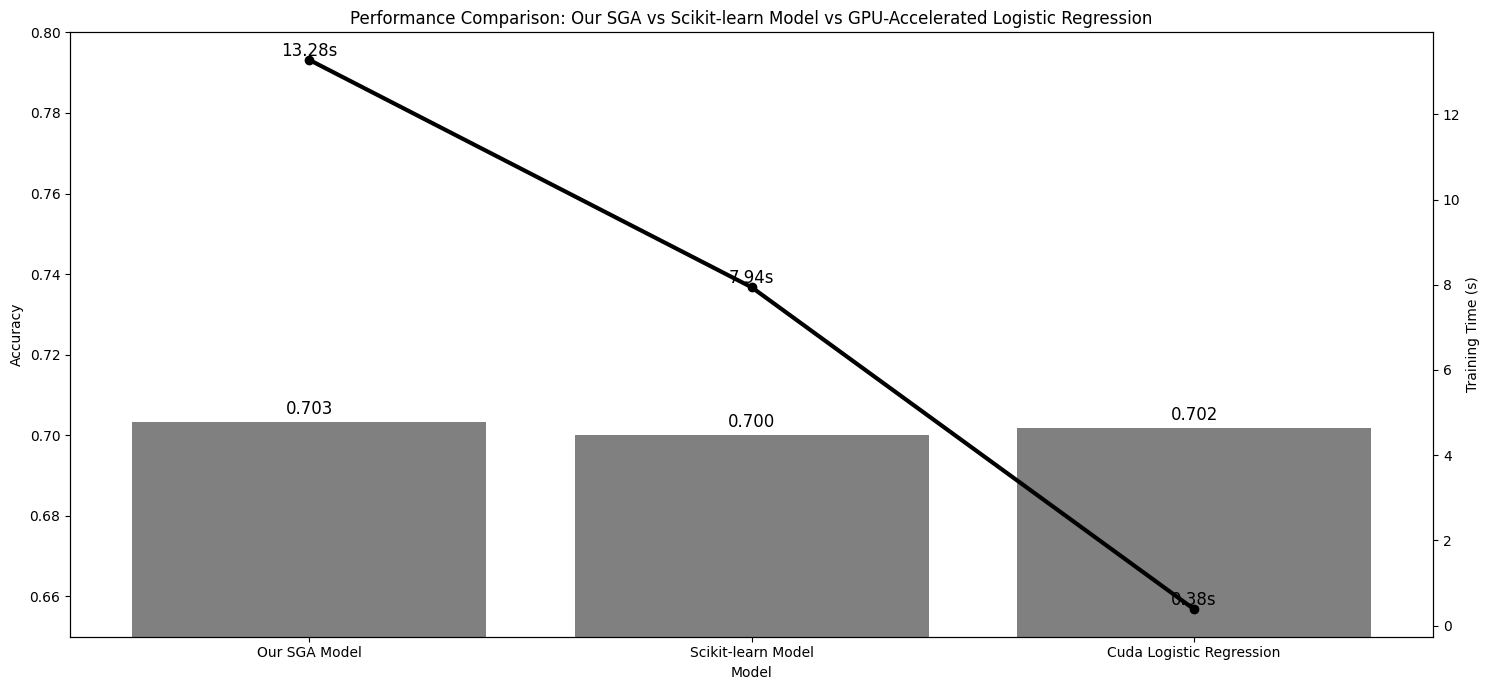

In [ ]:
models = ['Our SGA Model', 'Scikit-learn Model', 'Cuda Logistic Regression']
accuracy = [sga_acc, sk_acc, cuda_logistic_regression_ovr_acc]
model_time_vals = [sga_time, sk_time, cuda_ovr_time]

fig, ax1 = plt.subplots(figsize=(15,7))

ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
bars = ax1.bar(models, accuracy, color='grey', label='Accuracy')
ax1.set_ylim(0.65, 0.80)
for i, v in enumerate(accuracy):
    ax1.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=12)


ax2 = ax1.twinx()
ax2.set_ylabel('Training Time (s)')
ax2.plot(models, model_time_vals, color='black', marker='o', linewidth=3, label='Time')
for i, t in enumerate(model_time_vals):
    ax2.text(i, t + 0.1, f"{t:.2f}s", ha='center', fontsize=12)

plt.title('Performance Comparison: Our SGA vs Scikit-learn Model vs GPU-Accelerated Logistic Regression')
fig.tight_layout()
plt.show()

### Analysis between Our Best SGA model compared to Scikit learn and Cuda Accelerated regression

I have compared our best model tuned to the similar tuned for scikit learn logistic regression and then used the same tuned for the Cuda accelerated. From the graph, we can see that our modal too a long time to train 13.28s, compared to the scikit learn implementation 7.94s, and the CUDA accelerated regression was drastically reduced 0.38s. This is expected as both Our SGA model, and scikit learn run in series, meaning it is not dividing the task instead training them one at a time. Whereas CUDA accelerated takes advantage of GPU power to do parallel computation as such it is proving faster run time.

I do want to note that not all the models are running the same implementation for the model. For our model we are running stochastic gradient ascent, and for scikit learn we are using Saga solver. While scikit and CUDA are running the same tuned, the way it is implemented is different as well as CUDA team has not added support for method called "ovr" which allows us to perform a one vs rest. Instead, we are wrapping it in OneVsRestClassifier method which allows for Cuda acceleration.

As such the performance cannot be compared one to one, but looking at the result, it is quite similar and could be within margin of error between all the models around 70%. So the end user/customer can use any model to get the best result, but using CUDA acceleration is beneficial as they can save a lot of time when training the model.

In conclusion, using CUDA accelerated regression is recommended as the performance is similar with other models, but the times saved is significant compared to the other 2. If this is carried over to a dataset that has millions of data, then the time saved would be extremely helpful to save cost of training the model.



# Appendix

[1] WebFX, “How Much Should an Ecommerce Website Budget for Marketing?,” WebFX, 2025. [Online]. Available: https://www.webfx.com/industries/retail-ecommerce/ecommerce/budget/. [Accessed: Oct. 9, 2025].

[2] Red Stag Fulfillment, “How Many Products Does Amazon Carry?”, Red Stag Fulfillment, 2024. [Online]. Available: https://redstagfulfillment.com/how-many-products-does-amazon-carry/. [Accessed: 11-Oct-2025].